In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score , auc
from sklearn.model_selection import train_test_split

import cv2
#from google.colab.patches import cv2_imshow
from PIL import Image 
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Input, Dense,Conv2D , MaxPooling2D, Flatten,BatchNormalization,Dropout
from tensorflow.keras.preprocessing import image_dataset_from_directory
#import tensorflow_hub as hub 

from keras.applications import MobileNetV2
from keras.applications.vgg19 import VGG19
from keras.preprocessing.image import ImageDataGenerator
from keras.layers import GlobalAveragePooling2D

In [3]:
train_path = "C:/Plant Diseases/archive (1)/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
valid_path = "C:/Plant Diseases/archive (1)/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

In [4]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(
 train_path,
    batch_size=256,
  image_size=(224,224), shuffle=True
)

Found 70295 files belonging to 38 classes.


In [5]:
valid_data = tf.keras.preprocessing.image_dataset_from_directory(
 valid_path,
    batch_size=256,
  image_size=(224,224), shuffle=True
)

Found 17572 files belonging to 38 classes.


In [6]:
path = "C:/Plant Diseases/archive (1)/test/test"
test_folder = os.listdir(path)
test_folder[:5]

['AppleCedarRust1.JPG',
 'AppleCedarRust2.JPG',
 'AppleCedarRust3.JPG',
 'AppleCedarRust4.JPG',
 'AppleScab1.JPG']

In [7]:
len(train_data.class_names)

38

In [8]:
class_labels = train_data.class_names
class_labels

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [9]:
datagen = ImageDataGenerator(rescale=1.0/255.0)

# Use the 'datagen' to preprocess the images loaded by 'image_data_from_directory'
train_scaled_data = datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=256,shuffle=True,
    class_mode='sparse'
)

# test_scaled_data = datagen.flow_from_directory(
#     "/kaggle/input/100-bird-species/test",
#     target_size=(224, 224),
#     batch_size=256,shuffle=True
# )

valid_scaled_data = datagen.flow_from_directory(
    valid_path,
    target_size=(224, 224),
    batch_size=256,shuffle=True,
    class_mode='sparse'
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [10]:
train_scaled_data.class_indices

{'Apple___Apple_scab': 0,
 'Apple___Black_rot': 1,
 'Apple___Cedar_apple_rust': 2,
 'Apple___healthy': 3,
 'Blueberry___healthy': 4,
 'Cherry_(including_sour)___Powdery_mildew': 5,
 'Cherry_(including_sour)___healthy': 6,
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7,
 'Corn_(maize)___Common_rust_': 8,
 'Corn_(maize)___Northern_Leaf_Blight': 9,
 'Corn_(maize)___healthy': 10,
 'Grape___Black_rot': 11,
 'Grape___Esca_(Black_Measles)': 12,
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13,
 'Grape___healthy': 14,
 'Orange___Haunglongbing_(Citrus_greening)': 15,
 'Peach___Bacterial_spot': 16,
 'Peach___healthy': 17,
 'Pepper,_bell___Bacterial_spot': 18,
 'Pepper,_bell___healthy': 19,
 'Potato___Early_blight': 20,
 'Potato___Late_blight': 21,
 'Potato___healthy': 22,
 'Raspberry___healthy': 23,
 'Soybean___healthy': 24,
 'Squash___Powdery_mildew': 25,
 'Strawberry___Leaf_scorch': 26,
 'Strawberry___healthy': 27,
 'Tomato___Bacterial_spot': 28,
 'Tomato___Early_blight': 29,
 'Toma

In [11]:
for img, label in train_scaled_data:
    #print(img)
    print(label)
    break

[37. 11. 15. 24.  4. 33. 15. 34. 14. 29. 31.  2. 23. 11.  6. 24. 33. 16.
 15. 18. 35.  1. 23. 29.  4. 36. 23. 24. 28. 16.  6.  8. 25. 33. 36.  7.
  3. 33.  1. 26. 25. 24. 20.  0. 12. 36. 25. 20. 32. 20. 33.  0. 28. 29.
 23. 29. 15. 24. 31. 20.  6. 20.  9. 21. 35. 36. 27. 28.  7. 14. 31.  5.
 35.  1.  9. 34. 26. 18. 21. 24. 36. 10. 15. 14. 24. 20.  5.  7. 31.  0.
 32. 27. 21. 15. 18. 29. 34. 34. 36. 23. 23. 13. 37. 17. 10.  9. 30. 29.
 33.  4. 15. 32. 17. 15. 36. 12.  4. 17. 14. 25. 21.  1. 19.  6. 27.  3.
  9. 11.  3. 12. 33. 27. 28. 11. 17.  7. 10. 32. 37. 29.  3. 24.  6. 32.
 29. 19. 32. 15.  7. 17. 28. 13.  0. 27. 14. 29. 14.  1.  3. 27. 34. 18.
 20.  7. 12.  5. 30.  5. 32.  0. 37. 20. 31. 10. 21. 24.  3. 12. 26.  6.
 23.  1. 12.  7. 29.  9. 10. 19. 19. 20.  4. 35. 17.  1. 17. 12. 20. 35.
 37. 21.  3.  0.  0. 24. 24. 31. 36. 10. 10. 24.  5.  1. 14.  4. 27.  9.
 37.  4. 14. 27.  2. 17.  4. 22. 31. 24. 31. 23. 28. 27.  4. 19. 37. 16.
 11. 28.  9. 36. 36.  0.  3.  6. 36.  7. 13. 24.  8

In [12]:
label[10]

31.0

In [13]:
# Load pre-trained MobileNetV2 model
base_model = MobileNetV2(input_shape=(224,224,3),
                         include_top=False, weights='imagenet')

# Freeze the pre-trained layers
for layer in base_model.layers:
    layer.trainable = False

# Create a Sequential model
model = Sequential()

model.add(base_model)
model.add(GlobalAveragePooling2D())
model.add(Dense(100, activation='relu'))  # Add a dense layer with 1024 units
model.add(Dense(100, activation='relu'))   # Add another dense layer with 512 units
model.add(Dense(len(class_labels), activation='softmax'))

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 100)               128100    
                                                                 
 dense_1 (Dense)             (None, 100)               10100     
                                                                 
 dense_2 (Dense)             (None, 38)                3838      
                                                                 
Total params: 2400022 (9.16 MB)
Trainable params: 142

In [14]:
history = model.fit(train_scaled_data ,batch_size=256,epochs=10,
                verbose=1,
                validation_data=valid_scaled_data) # epochs=5

Epoch 1/10


275/275 [==============================] - 1822s 7s/step - loss: 0.6229 - accuracy: 0.8288 - val_loss: 0.2430 - val_accuracy: 0.9229
Epoch 2/10
275/275 [==============================] - 1024s 4s/step - loss: 0.1880 - accuracy: 0.9401 - val_loss: 0.2131 - val_accuracy: 0.9280
Epoch 3/10
275/275 [==============================] - 955s 3s/step - loss: 0.1377 - accuracy: 0.9550 - val_loss: 0.1564 - val_accuracy: 0.9483
Epoch 4/10
275/275 [==============================] - 780s 3s/step - loss: 0.1056 - accuracy: 0.9652 - val_loss: 0.1468 - val_accuracy: 0.9511
Epoch 5/10
275/275 [==============================] - 776s 3s/step - loss: 0.0874 - accuracy: 0.9710 - val_loss: 0.1224 - val_accuracy: 0.9571
Epoch 6/10
275/275 [==============================] - 893s 3s/step - loss: 0.0747 - accuracy: 0.9754 - val_loss: 0.1247 - val_accuracy: 0.9568
Epoch 7/10
275/275 [==============================] - 837s 3s/step - loss: 0.0607 - accuracy: 0.9802 - val_loss: 0.1190 - val_accuracy: 0.

In [15]:
# Save The Model
model.save("plant_disease_model_v4.h5")

In [16]:
loss,acc = model.evaluate(train_scaled_data)
print("Loss on Train data:",loss)
print("Accuracy on Train data:",acc)

loss1,acc1 = model.evaluate(valid_scaled_data)

print("Loss on Test data:",loss1)
print("Accuracy on Test data:",acc1)

275/275 [==============================] - 1330s 5s/step - loss: 0.0511 - accuracy: 0.9822
Loss on Train data: 0.051148563623428345
Accuracy on Train data: 0.9822035431861877
69/69 [==============================] - 322s 5s/step - loss: 0.1425 - accuracy: 0.9552
Loss on Test data: 0.14247222244739532
Accuracy on Test data: 0.9552128314971924


In [18]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

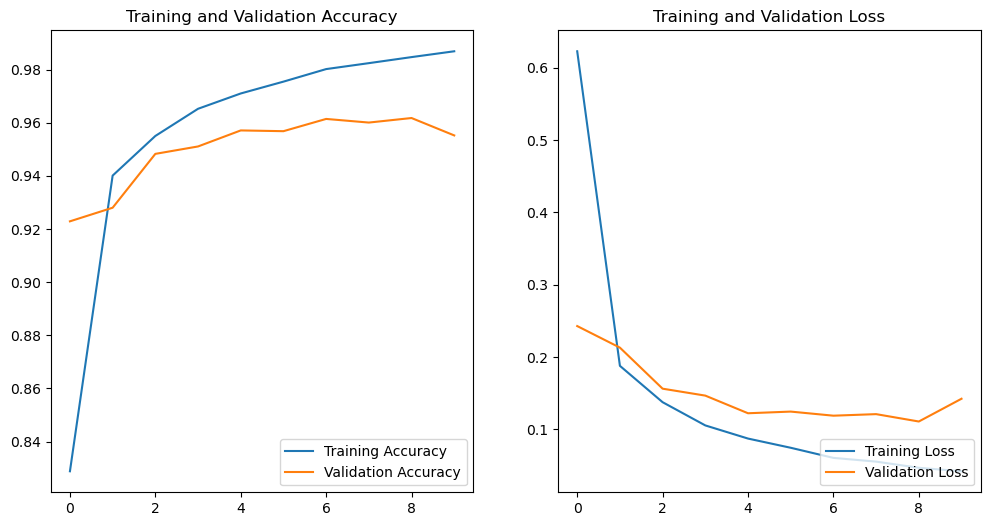

In [19]:
EPOCHS=10
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS),acc, label="Training Accuracy")
plt.plot(range(EPOCHS),val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")

#plt.figure(figsize=(6,6))
plt.subplot(1,2,2)
plt.plot(range(EPOCHS),loss, label="Training Loss")
plt.plot(range(EPOCHS),val_loss, label="Validation Loss")
plt.legend(loc="lower right")
plt.title("Training and Validation Loss")
plt.show()

(224, 224, 3)
(1, 224, 224, 3)


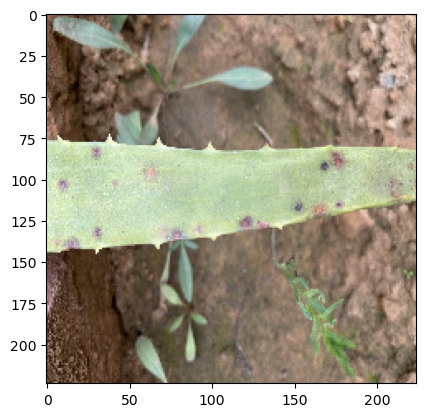

In [20]:
# Load the test image
from tensorflow.keras.preprocessing import image
#img_path = 'C:/Plant Diseases/archive (1)/test/test/AppleCedarRust1.JPG'
#img_path = "C:/Plant Diseases/archive (1)/test/test/AppleScab1.JPG"
img_path = "C:/Plant Diseases/New Image DB-20240226T231727Z-001/New Image DB/Leaf spot.jpg"
img = image.load_img(img_path, target_size=(224, 224))
#img
img_array = image.img_to_array(img)
print(img_array.shape) 
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
# Scale The Data
img_array = img_array/255
print(img_array.shape)
plt.imshow(img)

In [21]:
y_pred = model.predict(img_array)
y_pred

1/1 [==============================] - 2s 2s/step


array([[3.82857807e-02, 1.40110399e-06, 1.62495780e-05, 1.79066206e-10,
        9.56946735e-08, 3.27983139e-06, 7.71492182e-07, 6.60149317e-06,
        1.10966600e-02, 1.67621031e-01, 6.02177261e-06, 2.82645167e-04,
        2.52269047e-07, 2.85935698e-07, 3.28100271e-07, 3.24573875e-07,
        5.53607821e-01, 1.12304615e-05, 4.99128248e-04, 1.24268918e-04,
        7.01424980e-08, 2.59071142e-09, 3.40450548e-08, 1.81935342e-10,
        7.54920605e-12, 5.98179875e-03, 1.70735380e-04, 2.46257969e-07,
        1.09440521e-06, 3.77157198e-06, 2.22178727e-01, 1.67040469e-07,
        5.71755008e-05, 6.73683331e-10, 4.02670994e-05, 2.98646685e-09,
        5.91569687e-07, 1.18633864e-06]], dtype=float32)

In [22]:
np.argmax(y_pred[0])

16

In [23]:
len(y_pred[0])

38

In [24]:
class_labels[np.argmax(y_pred[0])]

'Peach___Bacterial_spot'

In [25]:
dict_class = {'Label':class_labels}
dict_class

{'Label': ['Apple___Apple_scab',
  'Apple___Black_rot',
  'Apple___Cedar_apple_rust',
  'Apple___healthy',
  'Blueberry___healthy',
  'Cherry_(including_sour)___Powdery_mildew',
  'Cherry_(including_sour)___healthy',
  'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
  'Corn_(maize)___Common_rust_',
  'Corn_(maize)___Northern_Leaf_Blight',
  'Corn_(maize)___healthy',
  'Grape___Black_rot',
  'Grape___Esca_(Black_Measles)',
  'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
  'Grape___healthy',
  'Orange___Haunglongbing_(Citrus_greening)',
  'Peach___Bacterial_spot',
  'Peach___healthy',
  'Pepper,_bell___Bacterial_spot',
  'Pepper,_bell___healthy',
  'Potato___Early_blight',
  'Potato___Late_blight',
  'Potato___healthy',
  'Raspberry___healthy',
  'Soybean___healthy',
  'Squash___Powdery_mildew',
  'Strawberry___Leaf_scorch',
  'Strawberry___healthy',
  'Tomato___Bacterial_spot',
  'Tomato___Early_blight',
  'Tomato___Late_blight',
  'Tomato___Leaf_Mold',
  'Tomato___Septoria_leaf_s

In [26]:
dict_class['Label'][16]

'Peach___Bacterial_spot'

In [27]:
import json

with open("class_labels.json",'w') as file:
    json.dump(dict_class,file)